<a href="https://colab.research.google.com/github/Parasshirishvaidya/aqi-regression-analysis/blob/main/notebooks/aqi_eda_log_transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.seasonal import seasonal_decompose

In [32]:
url= r"https://raw.githubusercontent.com/Parasshirishvaidya/aqi-regression-analysis/refs/heads/main/dataset/city_day.csv"
df=pd.read_csv(url)
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,1/1/2015,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,1/1/2015,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,1/1/2015,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,1/1/2015,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,1/1/2015,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [33]:
column_list=[ 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI',]

In [34]:
for col in column_list:
  if(df[col]<=0).any():
    df[f"{col}"]=np.log1p(df[col])
    print("Log1p applied to Columns with negative values or zeros")
  else:
    df[f"{col}"]=np.log(df[col])
    print("Applied Natural log")

Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros
Log1p applied to Columns with negative values or zeros


In [35]:
df.isnull().sum().sum()

np.int64(0)

In [36]:
df.columns

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [37]:
df['City'].unique()

array(['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore'], dtype=object)

In [38]:
pollutants = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3',
    'Benzene', 'Toluene', 'Xylene'
]

In [39]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,5.233372,5.404447,4.337002,4.056371,4.557776,3.013386,1.638518,3.655071,4.337979,2.203491,2.556675,1.635895,5.236886
std,0.954891,0.970700,0.923315,0.910735,0.932288,0.826326,0.604612,0.888427,0.921368,0.717400,0.762474,0.608108,0.952868
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.841822,5.017942,3.943522,3.655840,4.160444,2.610070,1.249902,3.234749,3.943522,1.805005,2.156403,1.255616,4.839451
50%,5.529429,5.708106,4.617099,4.343805,4.845761,3.269569,1.791759,3.929863,4.622027,2.405142,2.780681,1.785070,5.530222
75%,5.932776,6.111467,5.023881,4.737951,5.246498,3.653252,2.141242,4.332048,5.019925,2.779440,3.157000,2.143589,5.933306
max,6.216406,6.398595,5.303305,5.017280,5.525453,3.931826,2.397895,4.615121,5.303305,3.044522,3.433987,2.397895,6.216606


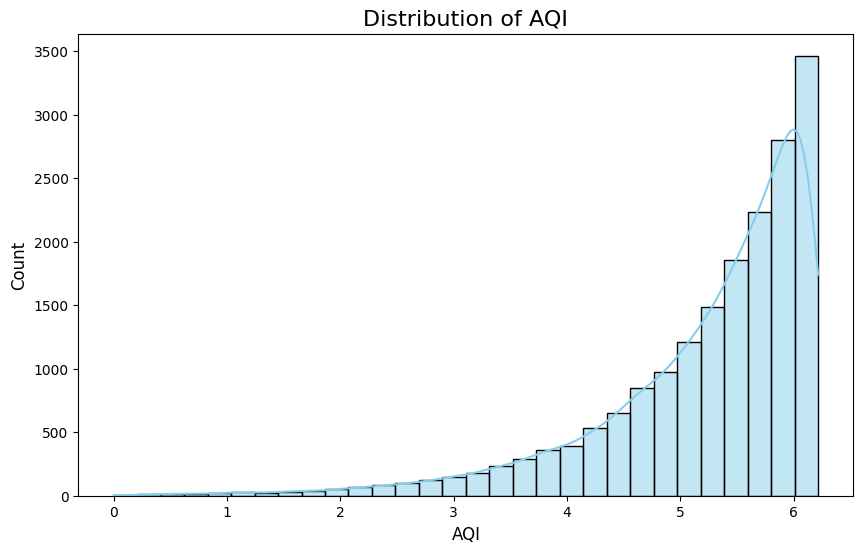

In [40]:
plt.figure(figsize=(10,6))
sns.histplot(df['AQI'], bins=30, kde=True, color='skyblue')  # kde=True adds a smooth density curve
plt.title("Distribution of AQI", fontsize=16)
plt.xlabel("AQI", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

In [41]:
# Converting df to Yearly based data

# Convert 'Datetime' column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# This allows grouping data year-wise
df['Year'] = df['Datetime'].dt.year


# Group by BOTH Year and City
# This preserves city-wise structure instead of mixing all cities together
yearly_city_df = df.groupby(['Year', 'City']).mean(numeric_only=True).reset_index()

yearly_city_df

,Year,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0,2015,Bangalore,5.203034,5.495067,4.218255,4.033143,4.593878,3.099856,1.610075,3.632848,4.348712,2.219959,2.624122,1.651606,5.184623
1,2015,Chennai,5.218479,5.467114,4.369854,4.028019,4.551418,3.029373,1.641597,3.673727,4.326989,2.171871,2.452433,1.643390,5.230600
2,2015,Delhi,5.280699,5.348179,4.319930,4.063465,4.516898,3.062285,1.631643,3.619609,4.307361,2.157823,2.643464,1.677489,5.252181
3,2015,Kolkata,5.233833,5.495468,4.379650,4.056834,4.574049,2.992939,1.668721,3.544520,4.354142,2.219234,2.521788,1.614334,5.254466
4,2015,Mumbai,5.246180,5.368033,4.295762,4.088434,4.556100,3.039969,1.646635,3.708949,4.378645,2.155535,2.642130,1.651483,5.247327
5,2016,Bangalore,5.182829,5.375888,4.303916,3.997297,4.577051,2.996681,1.691644,3.626560,4.317684,2.160575,2.563429,1.617103,5.262525
6,2016,Chennai,5.233261,5.434342,4.365419,4.063575,4.545943,3.069929,1.660516,3.640588,4.281571,2.224322,2.570744,1.630828,5.306562
7,2016,Delhi,5.136519,5.363660,4.277072,4.056900,4.520350,2.992795,1.637080,3.649055,4.326934,2.165336,2.567199,1.622716,5.274863
8,2016,Kolkata,5.261408,5.432153,4.349681,3.986490,4.486172,3.032232,1.658050,3.741750,4.353331,2.130701,2.546066,1.659660,5.137708
9,2016,Mumbai,5.207570,5.437000,4.328966,4.008513,4.638225,2.988839,1.642274,3.626281,4.329646,2.193774,2.469474,1.617082,5.157726


In [42]:
year_city_aqi = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()
result = year_city_aqi.loc[
    year_city_aqi.groupby('Year')['AQI'].idxmax()
]
result = result.sort_values('Year')
print(result)

    Year       City       AQI
3   2015    Kolkata  5.254466
6   2016    Chennai  5.306562
12  2017      Delhi  5.270698
19  2018     Mumbai  5.286015
23  2019    Kolkata  5.345146
25  2020  Bangalore  5.310600
31  2021    Chennai  5.285052
39  2022     Mumbai  5.264486
42  2023      Delhi  5.343522
48  2024    Kolkata  5.303905


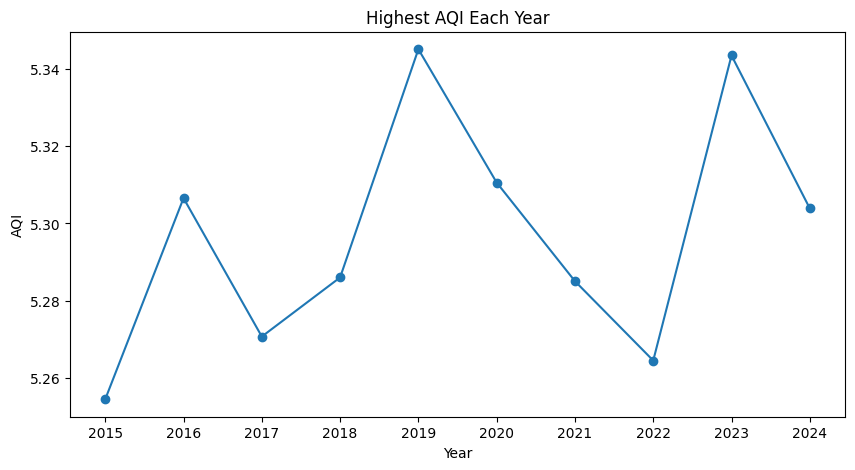

In [43]:
plt.figure(figsize=(10,5))
plt.plot(result['Year'], result['AQI'], marker='o')
plt.xticks(result['Year'])
plt.title("Highest AQI Each Year")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.show()

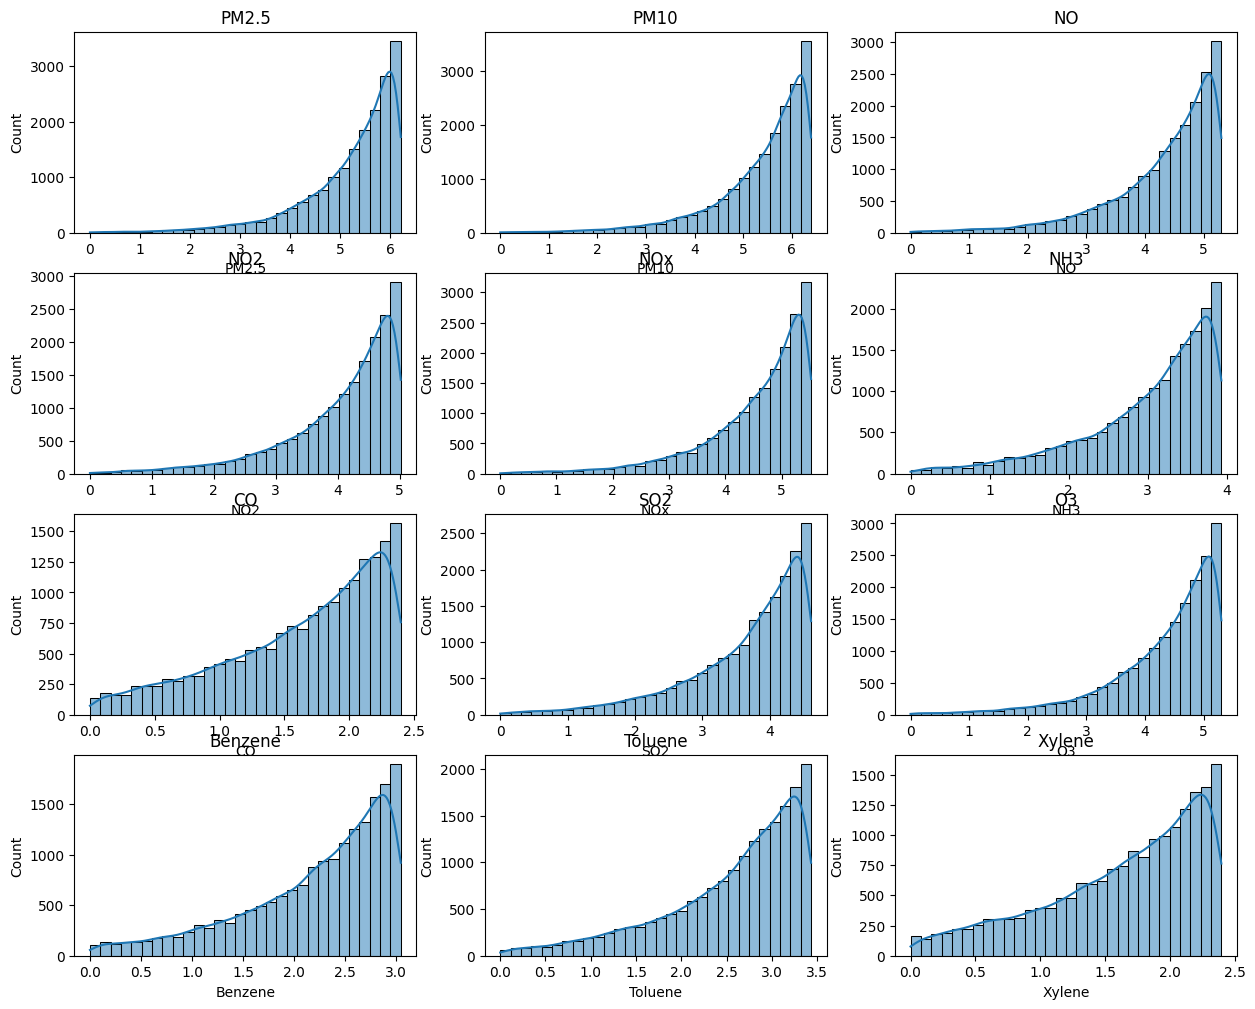

In [44]:
# Create subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(pollutants):
    sns.histplot(df[col], bins=30, ax=axes[i], kde=True)
    axes[i].set_title(col)


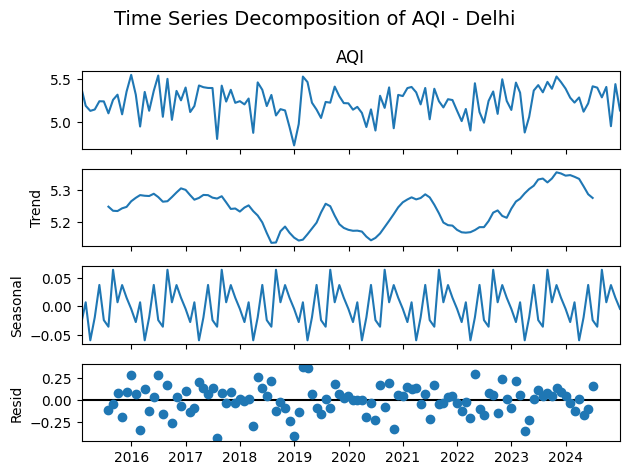

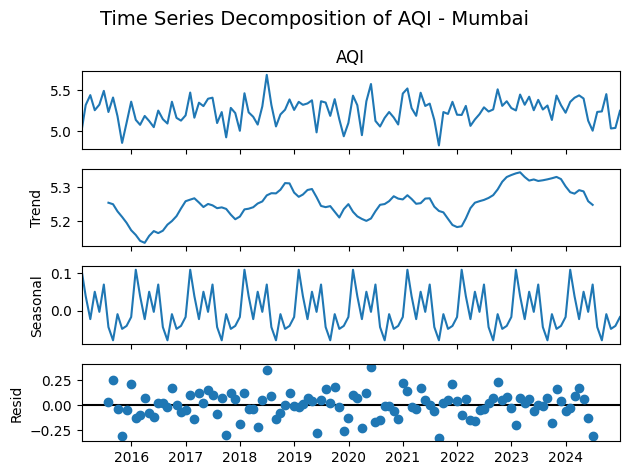

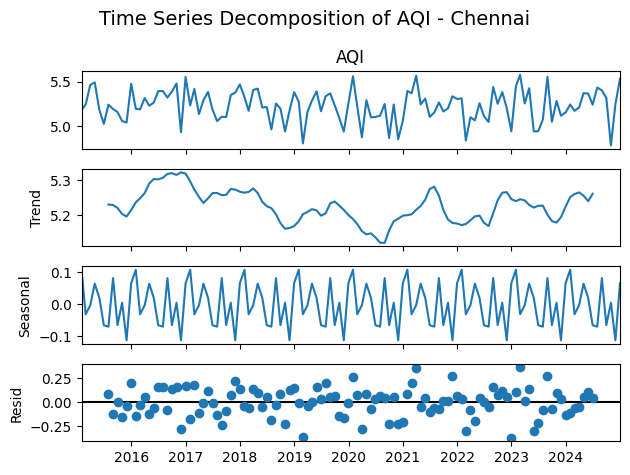

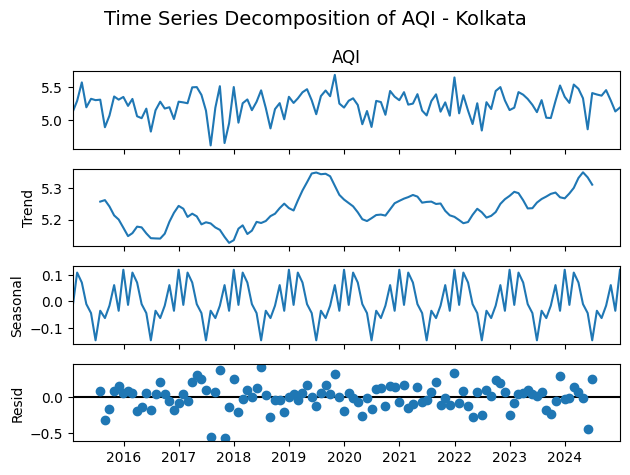

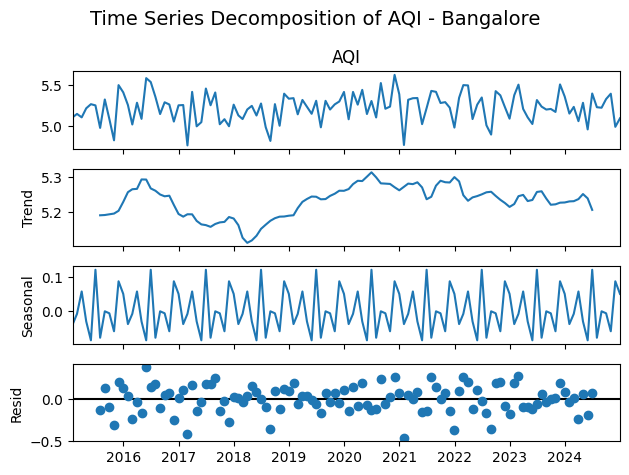

In [45]:
# ================================
# TIME SERIES DECOMPOSITION FOR ALL CITIES
# ================================

# --------------------------------
# STEP 1: Ensure 'Datetime' is a column (not index)
# --------------------------------
# This avoids errors if the cell is run multiple times
if df.index.name == 'Datetime':
    df = df.reset_index()

# --------------------------------
# STEP 2: Convert 'Datetime' to proper datetime format
# --------------------------------
# Required because time series methods need datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# --------------------------------
# STEP 3: Sort data by date
# --------------------------------
# Ensures correct chronological order for time series analysis
df = df.sort_values('Datetime')

# --------------------------------
# STEP 4: Set 'Datetime' as index
# --------------------------------
# Required for resampling and decomposition
df.set_index('Datetime', inplace=True)

# --------------------------------
# STEP 5: Loop through each city
# --------------------------------
# We do decomposition separately because each city has its own pattern
for city in df['City'].unique():

    # --------------------------------
    # STEP 5.1: Filter data for one city
    # --------------------------------
    # Decomposition requires a single continuous time series
    df_city = df[df['City'] == city]

    # --------------------------------
    # STEP 5.2: Select AQI series
    # --------------------------------
    # We are analyzing AQI behavior over time
    aqi_series = df_city['AQI']

    # --------------------------------
    # STEP 5.3: Resample to monthly data
    # --------------------------------
    # WHY: Daily data is too dense → cluttered plots
    # Monthly average reduces noise and improves visualization
    aqi_monthly = aqi_series.resample('ME').mean()

    # --------------------------------
    # STEP 5.4: Handle missing values (if any)
    # --------------------------------
    # Decomposition requires continuous data
    aqi_monthly = aqi_monthly.interpolate()

    # --------------------------------
    # STEP 5.5: Apply decomposition
    # --------------------------------
    # model='additive' → AQI = Trend + Seasonal + Noise
    # period=12 → yearly seasonality (since monthly data)
    result = seasonal_decompose(aqi_monthly, model='additive', period=12)

    # --------------------------------
    # STEP 5.6: Plot results
    # --------------------------------
    # Shows Observed, Trend, Seasonal, Residual
    result.plot()

    # Add title for clarity (which city this plot belongs to)
    plt.suptitle(f"Time Series Decomposition of AQI - {city}", fontsize=14)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Display plot
    plt.show()

In [46]:
# Check if 'Datetime' is already the index and reset it if it is

if df.index.name == 'Datetime':
    df = df.reset_index()

df['Datetime'] = pd.to_datetime(df['Datetime'])


# Create a function to map months → seasons

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5, 6]:
        return 'Summer'
    elif month in [7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

# Apply the function to create 'Season' column

# Extract month from Datetime and map to season
df['Season'] = df['Datetime'].dt.month.map(get_season)



# Verify that seasons are correctly assigned
print(df[['Datetime', 'Season']])


#  Convert Season to categorical
# Helps in regression (statsmodels treats it properly)
df['Season'] = df['Season'].astype('category')

        Datetime  Season
0     2015-01-01  Winter
1     2015-01-01  Winter
2     2015-01-01  Winter
3     2015-01-01  Winter
4     2015-01-01  Winter
...          ...     ...
18260 2024-12-31  Winter
18261 2024-12-31  Winter
18262 2024-12-31  Winter
18263 2024-12-31  Winter
18264 2024-12-31  Winter

[18265 rows x 2 columns]


In [47]:
# Calculates spread/variability of AQI within each season in each city

print(df.groupby(['City','Season'])['AQI'].std())

City       Season      
Bangalore  Monsoon         0.976523
           Post-Monsoon    0.949179
           Summer          0.961518
           Winter          0.971113
Chennai    Monsoon         0.947849
           Post-Monsoon    1.048597
           Summer          0.945486
           Winter          0.923143
Delhi      Monsoon         0.924814
           Post-Monsoon    0.901698
           Summer          0.970025
           Winter          0.974687
Kolkata    Monsoon         0.971562
           Post-Monsoon    0.974855
           Summer          0.970462
           Winter          0.872787
Mumbai     Monsoon         0.962494
           Post-Monsoon    0.985122
           Summer          0.935580
           Winter          0.901468
Name: AQI, dtype: float64


/tmp/ipykernel_3652/1305574593.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['City','Season'])['AQI'].std())


In [48]:
# Calculates spread/variability of AQI within each season in each city in from 2015 to 2024

df.groupby(['Year','City','Season'])['AQI'].std()

/tmp/ipykernel_3652/2054187842.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Year','City','Season'])['AQI'].std()


Year  City       Season      
2015  Bangalore  Monsoon         1.066908
                 Post-Monsoon    1.036112
                 Summer          0.928835
                 Winter          1.080002
      Chennai    Monsoon         0.786440
                                   ...   
2024  Kolkata    Winter          0.862129
      Mumbai     Monsoon         0.928935
                 Post-Monsoon    1.109139
                 Summer          1.074125
                 Winter          0.798604
Name: AQI, Length: 200, dtype: float64

In [49]:
# Average AQI by Season AND City from 2015 to 2024
df.groupby(['Year','City','Season'])['AQI'].mean().unstack()

/tmp/ipykernel_3652/617288354.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Year','City','Season'])['AQI'].mean().unstack()


Season           Monsoon  Post-Monsoon    Summer    Winter
Year City                                                 
2015 Bangalore  5.129745      5.157092  5.209970  5.225021
     Chennai    5.199015      5.050237  5.291413  5.302698
     Delhi      5.226753      5.221738  5.191713  5.380774
     Kolkata    5.083551      5.331134  5.346302  5.252728
     Mumbai     5.277156      4.973705  5.379568  5.223030
2016 Bangalore  5.263695      5.160667  5.374514  5.179481
     Chennai    5.367997      5.211053  5.301322  5.315501
     Delhi      5.200485      5.308979  5.347036  5.230432
     Kolkata    5.196339      5.100687  5.015819  5.266660
     Mumbai     5.197166      5.144651  5.150724  5.136006
2017 Bangalore  5.230726      5.041240  5.229732  5.104645
     Chennai    5.089151      5.363536  5.250247  5.372039
     Delhi      5.156784      5.301323  5.405253  5.183988
     Kolkata    5.094980      4.788727  5.378930  5.341510
     Mumbai     5.085491      5.253244  5.365996  5.214681
2018 Bangalore  5.021245      5.195934  5.212295  5.186303
     Chennai    5.138024      5.055979  5.313232  5.298384
     Delhi      5.183219      5.044337  5.224208  5.066079
     Kolkata    5.066973      5.131186  5.294377  5.182400
     Mumbai     5.193351      5.324524  5.310805  5.321033
2019 Bangalore  5.164165      5.281878  5.252606  5.305122
     Chennai    5.314210      5.017741  5.252759  5.123579
     Delhi      5.290042      5.262253  5.223678  5.233201
     Kolkata    5.389446      5.470166  5.317195  5.253015
     Mumbai     5.308740      5.040324  5.264880  5.258034
2020 Bangalore  5.280796      5.428059  5.287424  5.293069
     Chennai    5.081205      5.053282  5.091838  5.279842
     Delhi      5.290780      5.121815  5.030064  5.210175
     Kolkata    5.211792      5.396536  5.045357  5.304515
     Mumbai     5.149109      5.123537  5.254580  5.406993
2021 Bangalore  5.377027      5.258707  5.230259  5.013458
     Chennai    5.196186      5.267518  5.308611  5.355842
     Delhi      5.268770      5.262178  5.248419  5.309022
     Kolkata    5.266289      5.164058  5.209338  5.439622
     Mumbai     5.061398      5.283538  5.324826  5.337516
2022 Bangalore  5.106920      5.304637  5.299063  5.305166
     Chennai    5.246719      5.295770  5.135109  5.038581
     Delhi      5.235130      5.373504  5.116746  5.102891
     Kolkata    5.288146      5.398515  5.040977  5.199778
     Mumbai     5.337682      5.337651  5.174936  5.261464
2023 Bangalore  5.215810      5.337390  5.163365  5.410756
     Chennai    5.228187      5.202212  5.141881  5.387205
     Delhi      5.399738      5.496157  5.184771  5.397798
     Kolkata    5.118198      5.402985  5.260856  5.314953
     Mumbai     5.238978      5.378782  5.345479  5.304264
2024 Bangalore  5.260134      5.195799  5.172138  5.158569
     Chennai    5.384869      5.012943  5.297125  5.319439
     Delhi      5.364777      5.194526  5.261068  5.216414
     Kolkata    5.401349      5.210838  5.263164  5.322395
     Mumbai     5.308577      5.033649  5.242818  5.337452

In [50]:
# Average AQI in each City from 2015 to 2024

df.groupby(['Year','City'])['AQI'].mean().unstack()

City,Bangalore,Chennai,Delhi,Kolkata,Mumbai
Year,,,,,
2015,5.184623,5.230600,5.252181,5.254466,5.247327
2016,5.262525,5.306562,5.274863,5.137708,5.157726
2017,5.167638,5.258606,5.270698,5.199495,5.239139
2018,5.154997,5.222416,5.144825,5.182175,5.286015
2019,5.248155,5.197118,5.249200,5.345146,5.236718
2020,5.310600,5.129483,5.155673,5.210158,5.244122
2021,5.218549,5.285052,5.270791,5.272908,5.254657
2022,5.253069,5.166290,5.186079,5.202186,5.264486
2023,5.266668,5.234209,5.343522,5.261990,5.314038


In [54]:
season_avg = df.groupby("Season")["AQI"].mean()

/tmp/ipykernel_3652/1887638743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_avg = df.groupby("Season")["AQI"].mean()


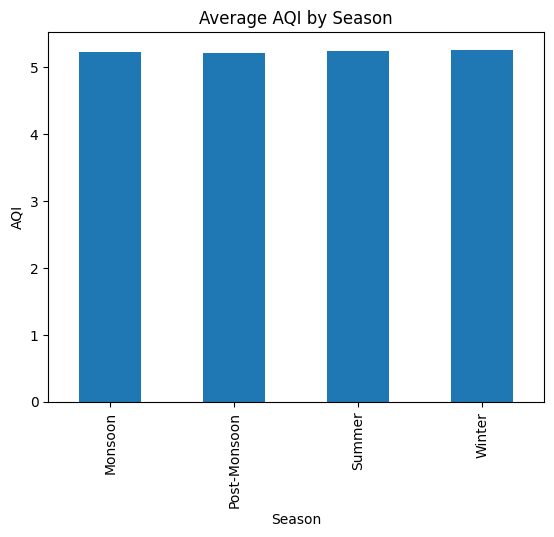

In [55]:
season_avg.plot(kind='bar', title='Average AQI by Season')
plt.ylabel('AQI')
plt.show()

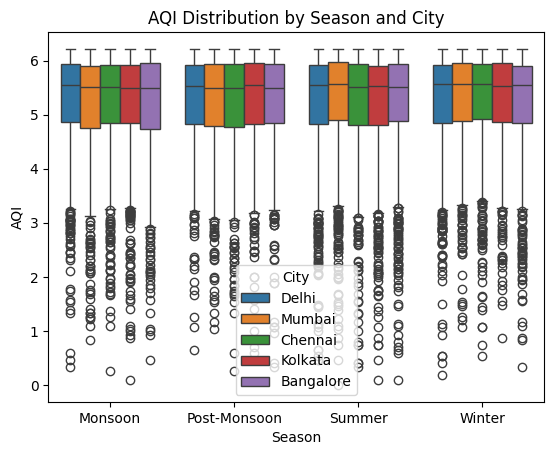

In [52]:
sns.boxplot(x='Season', y='AQI', hue='City', data=df)
plt.title('AQI Distribution by Season and City')
plt.show()

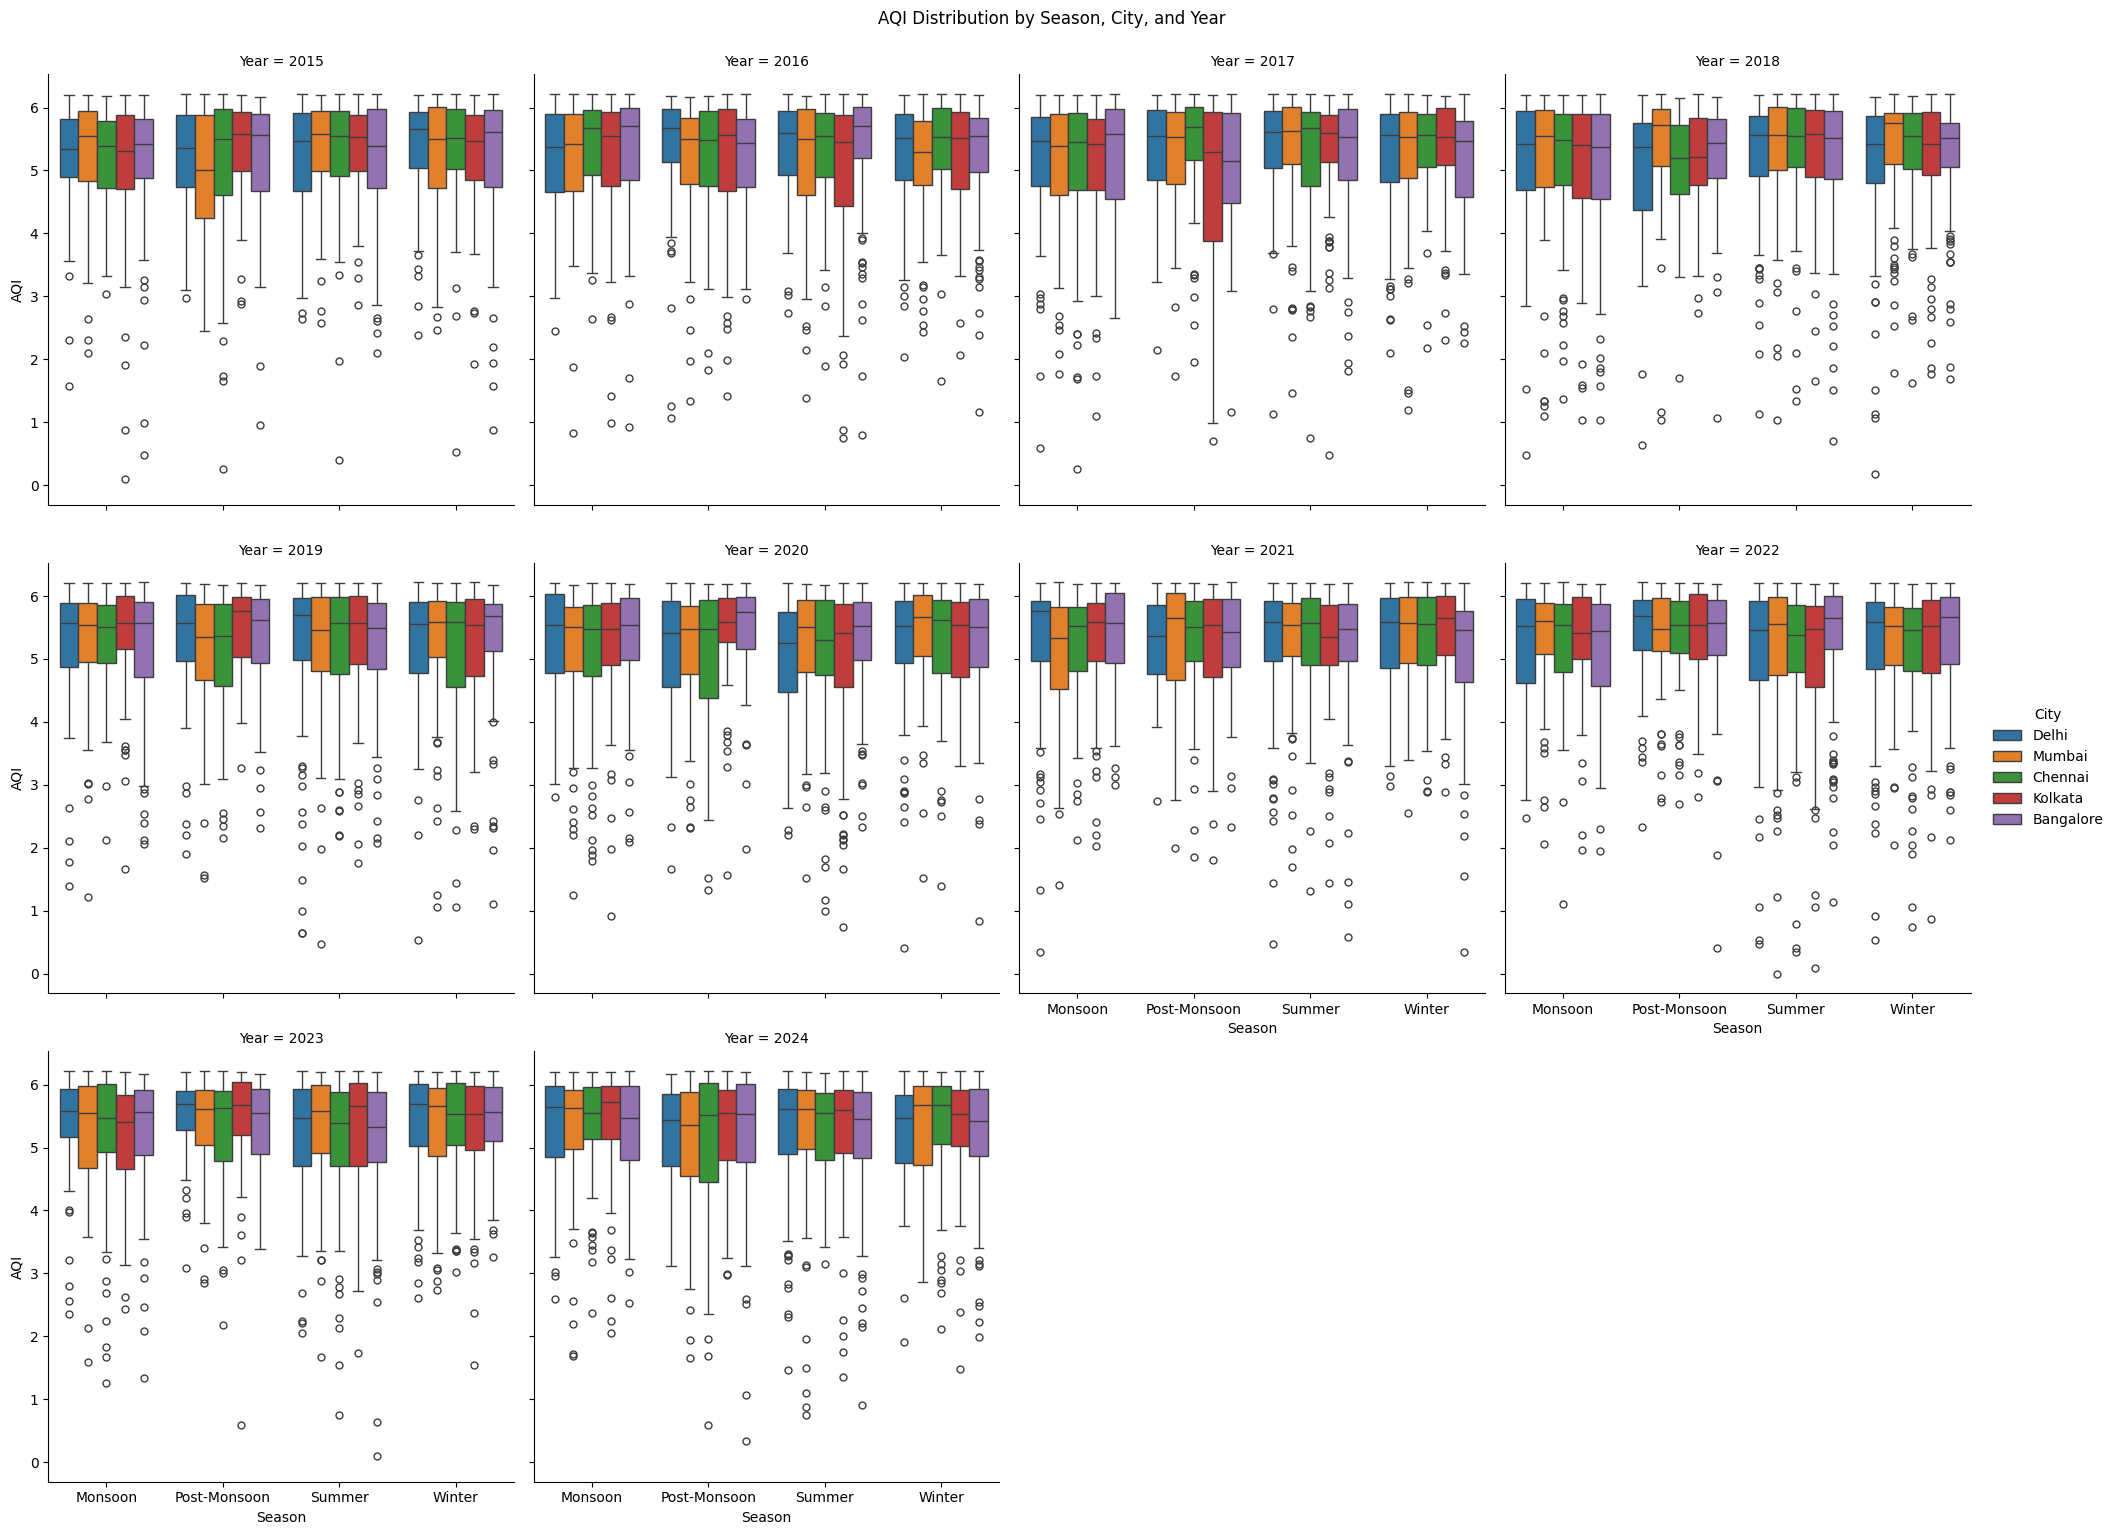

In [62]:
# Faceting splits the plot by Year, so you can compare seasonal patterns across years
g = sns.catplot(
    x='Season',
    y='AQI',
    hue='City',
    col='Year',            # <-- THIS adds Year dimension
    data=df,
    kind='box',
    col_wrap=4             # WHY: Keeps layout readable (4 plots per row)
)

# WHY: Adds a clear title for interpretation
g.fig.suptitle('AQI Distribution by Season, City, and Year', y=1.02)

plt.show()

In [63]:
from scipy.stats import shapiro, levene

alpha = 0.05  # significance level

for city in df['City'].unique():
    print("\n" + "="*60)
    print(f"ASSUMPTION CHECKS FOR CITY: {city}")
    print("="*60)

    city_df = df[df['City']==city]

    # -------------------------------
    # STEP 1: Normality per Season x Year group
    # -------------------------------
    print("\nNormality Check (Shapiro-Wilk) per Season x Year group:")

    normality_flag = True
    for season in city_df['Season'].unique():
        for year in city_df['Year'].unique():
            group = city_df[(city_df['Season']==season) & (city_df['Year']==year)]['AQI']
            if len(group) >= 3:  # Shapiro-Wilk requires at least 3 points
                stat, p = shapiro(group)
                result = "Normal" if p > alpha else "Not Normal"
                if p <= alpha:
                    normality_flag = False
                print(f"{season}-{year}: p={p:.4f} → {result}")

    # -------------------------------
    # STEP 2: Homogeneity of variances (Levene's test)
    # -------------------------------
    # Use AQI values grouped by Season
    groups = [city_df[city_df['Season']==s]['AQI'] for s in city_df['Season'].unique()]
    stat, p = levene(*groups)
    variance_result = "Equal variances" if p > alpha else "Unequal variances"
    print(f"\nHomogeneity of variances across Seasons: p={p:.4f} → {variance_result}")

    # -------------------------------
    # STEP 3: Recommendation
    # -------------------------------
    if not normality_flag or p <= alpha:
        print("\n=> ANOVA assumptions NOT satisfied. Consider using non-parametric alternatives (e.g., aligned-rank ANOVA).")
    else:
        print("\n=> ANOVA assumptions satisfied. You can proceed with Two-way ANOVA.")


ASSUMPTION CHECKS FOR CITY: Delhi

Normality Check (Shapiro-Wilk) per Season x Year group:
Winter-2015: p=0.0000 → Not Normal
Winter-2016: p=0.0000 → Not Normal
Winter-2017: p=0.0000 → Not Normal
Winter-2018: p=0.0000 → Not Normal
Winter-2019: p=0.0000 → Not Normal
Winter-2020: p=0.0000 → Not Normal
Winter-2021: p=0.0000 → Not Normal
Winter-2022: p=0.0000 → Not Normal
Winter-2023: p=0.0000 → Not Normal
Winter-2024: p=0.0000 → Not Normal
Summer-2015: p=0.0000 → Not Normal
Summer-2016: p=0.0000 → Not Normal
Summer-2017: p=0.0000 → Not Normal
Summer-2018: p=0.0000 → Not Normal
Summer-2019: p=0.0000 → Not Normal
Summer-2020: p=0.0000 → Not Normal
Summer-2021: p=0.0000 → Not Normal
Summer-2022: p=0.0000 → Not Normal
Summer-2023: p=0.0000 → Not Normal
Summer-2024: p=0.0000 → Not Normal
Monsoon-2015: p=0.0000 → Not Normal
Monsoon-2016: p=0.0000 → Not Normal
Monsoon-2017: p=0.0000 → Not Normal
Monsoon-2018: p=0.0000 → Not Normal
Monsoon-2019: p=0.0000 → Not Normal
Monsoon-2020: p=0.0000 → Not

In [59]:
# ==========================================================
# NON-PARAMETRIC 2-WAY ANOVA (Scheirer-Ray-Hare)
# Tests: Season effect, Year effect, and Interaction effect
# Works when normality / equal variance is violated
# ==========================================================

from scipy.stats import rankdata, chi2

alpha = 0.05

# Function to perform Scheirer-Ray-Hare test
def srh_test(df, dv, factor1, factor2):
    """
    df      : pandas DataFrame
    dv      : dependent variable column (e.g., 'AQI')
    factor1 : first factor column (e.g., 'Season')
    factor2 : second factor column (e.g., 'Year')
    Returns : DataFrame with H-statistics and p-values
    """
    df = df.copy()
    df['rank'] = rankdata(df[dv])
    grand_mean = df['rank'].mean()

    # Sums of squares for factors
    n_total = len(df)
    ss_factor1 = sum([len(sub) * (sub['rank'].mean() - grand_mean)**2
                      for name, sub in df.groupby(factor1)])
    ss_factor2 = sum([len(sub) * (sub['rank'].mean() - grand_mean)**2
                      for name, sub in df.groupby(factor2)])
    # Interaction
    ss_inter = sum([len(sub) * (sub['rank'].mean() - grand_mean
                                - (df[df[factor1]==name1]['rank'].mean() - grand_mean)
                                - (df[df[factor2]==name2]['rank'].mean() - grand_mean))**2
                     for (name1, name2), sub in df.groupby([factor1, factor2])])

    # Total sum of squares
    ss_total = sum((df['rank'] - grand_mean)**2)

    # Residuals / error
    ss_error = ss_total - ss_factor1 - ss_factor2 - ss_inter

    # Degrees of freedom
    df1 = df[factor1].nunique() - 1
    df2 = df[factor2].nunique() - 1
    df_int = (df[factor1].nunique() - 1) * (df[factor2].nunique() - 1)

    # H-statistics
    H_factor1 = (12 / (n_total*(n_total+1))) * ss_factor1
    H_factor2 = (12 / (n_total*(n_total+1))) * ss_factor2
    H_inter = (12 / (n_total*(n_total+1))) * ss_inter

    # p-values
    p_factor1 = 1 - chi2.cdf(H_factor1, df1)
    p_factor2 = 1 - chi2.cdf(H_factor2, df2)
    p_inter = 1 - chi2.cdf(H_inter, df_int)

    results = pd.DataFrame({
        'Effect': [factor1, factor2, f'{factor1}x{factor2}'],
        'H': [H_factor1, H_factor2, H_inter],
        'df': [df1, df2, df_int],
        'p-value': [p_factor1, p_factor2, p_inter],
        'Significant': ['Yes' if p < alpha else 'No' for p in [p_factor1, p_factor2, p_inter]]
    })
    return results

# ------------------------------
# Run SRH test city-wise
# ------------------------------
for city in df['City'].unique():
    print("\n" + "="*70)
    print(f"CITY: {city}")
    print("="*70)

    city_df = df[df['City'] == city].copy()
    srh_results = srh_test(city_df, dv='AQI', factor1='Season', factor2='Year')
    print(srh_results)


CITY: Delhi
        Effect          H  df   p-value Significant
0       Season   0.512975   3  0.916032          No
1         Year  12.572318   9  0.182932          No
2  SeasonxYear  31.102568  27  0.266948          No

CITY: Mumbai


/tmp/ipykernel_3652/3464795143.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(factor1)])
/tmp/ipykernel_3652/3464795143.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (name1, name2), sub in df.groupby([factor1, factor2])])
/tmp/ipykernel_3652/3464795143.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(factor1)])
/tmp/ipykernel_3652/3464795143.py:

        Effect          H  df   p-value Significant
0       Season   5.763671   3  0.123692          No
1         Year   8.502040   9  0.484448          No
2  SeasonxYear  24.540912  27  0.600173          No

CITY: Chennai
        Effect          H  df   p-value Significant
0       Season   3.643113   3  0.302670          No
1         Year   7.686139   9  0.566059          No
2  SeasonxYear  24.453995  27  0.605032          No

CITY: Kolkata


/tmp/ipykernel_3652/3464795143.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(factor1)])
/tmp/ipykernel_3652/3464795143.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (name1, name2), sub in df.groupby([factor1, factor2])])
/tmp/ipykernel_3652/3464795143.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(factor1)])
/tmp/ipykernel_3652/3464795143.py:

        Effect          H  df   p-value Significant
0       Season   2.979049   3  0.394867          No
1         Year  10.214200   9  0.333425          No
2  SeasonxYear  33.618740  27  0.177412          No

CITY: Bangalore
        Effect          H  df   p-value Significant
0       Season   0.781253   3  0.853946          No
1         Year   9.388841   9  0.402182          No
2  SeasonxYear  32.345853  27  0.219517          No


/tmp/ipykernel_3652/3464795143.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(factor1)])
/tmp/ipykernel_3652/3464795143.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (name1, name2), sub in df.groupby([factor1, factor2])])


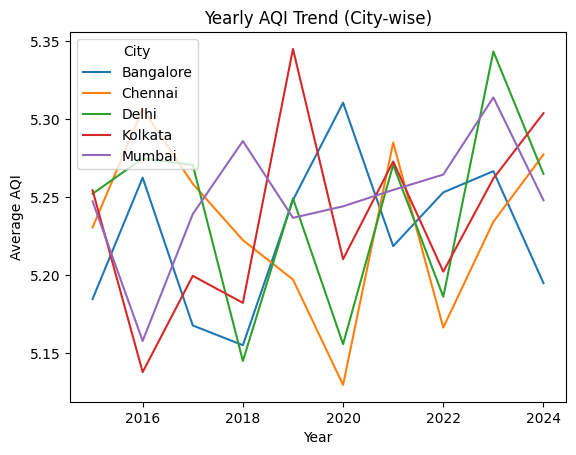

In [64]:
# Group by BOTH Year and City
yearly_city = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()

sns.lineplot(data=yearly_city, x='Year', y='AQI', hue='City')

plt.title('Yearly AQI Trend (City-wise)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.show()

In [65]:
# Defining Covid Period

def covid_phase(date):
    if date < pd.Timestamp('2020-03-25'):
        return 'Pre-COVID'
    elif date <= pd.Timestamp('2020-05-31'):
        return 'Lockdown'
    else:
        return 'Post-Lockdown'

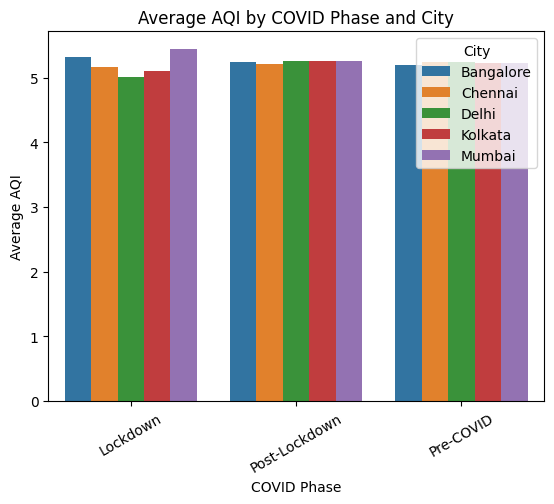

In [66]:

# Creating dataframe for Covid Period
df['COVID_Phase'] = df['Datetime'].apply(covid_phase)
df.groupby('COVID_Phase')['AQI'].mean()

#  Group by BOTH COVID_Phase and City
covid_city = df.groupby(['COVID_Phase', 'City'])['AQI'].mean().reset_index()


sns.barplot(data=covid_city, x='COVID_Phase', y='AQI', hue='City')
plt.title('Average AQI by COVID Phase and City')
plt.xlabel('COVID Phase')
plt.ylabel('Average AQI')
plt.xticks(rotation=30)

plt.show()

In [67]:
df.groupby(['City','COVID_Phase'])['AQI'].mean().unstack()

COVID_Phase,Lockdown,Post-Lockdown,Pre-COVID
City,,,
Bangalore,5.319186,5.247117,5.204526
Chennai,5.160292,5.219393,5.243268
Delhi,5.005487,5.256658,5.236169
Kolkata,5.108744,5.256593,5.224380
Mumbai,5.443792,5.259196,5.233502


<Axes: xlabel='Datetime', ylabel='AQI_Smooth'>

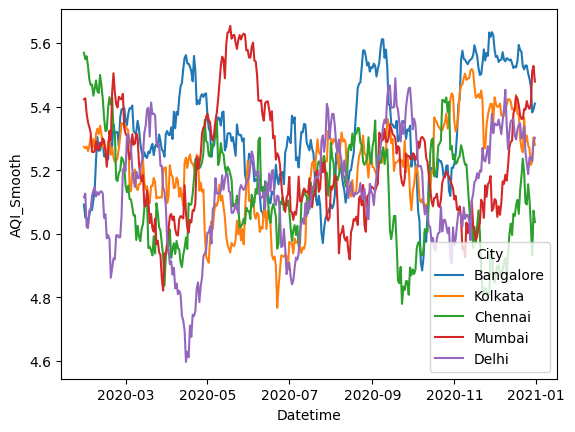

In [68]:
# Taking moving average to visualize the trend

# Defining dataframe for the lockdown period
df2020 = df.loc[(df['Datetime'] >= '2020-01-01') & (df['Datetime'] <= '2020-12-31')].copy()

# Apply 30-day moving average
df2020['AQI_Smooth'] = df2020.groupby('City')['AQI'].transform(lambda x: x.rolling(30).mean())

sns.lineplot(x='Datetime', y='AQI_Smooth', hue='City', data=df2020)

<Axes: xlabel='COVID_Phase', ylabel='AQI'>

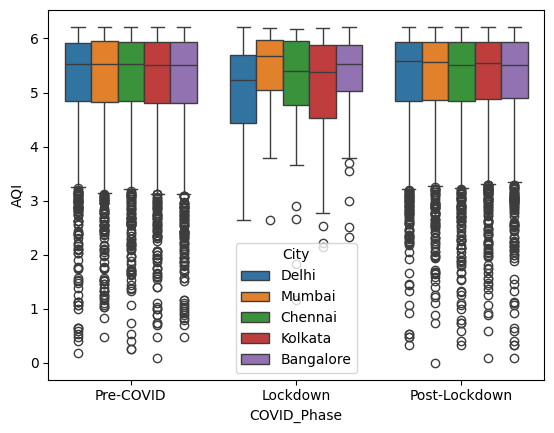

In [69]:
sns.boxplot(x='COVID_Phase', y='AQI', hue='City', data=df)

In [76]:
cities=['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore']

In [77]:
# Make sure pandas shows all columns in one line
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

threshold = 0.3  # strong correlation threshold

for city in cities:
    city_df = df[df['City'] == city]

    # Compute correlation matrix
    corr_matrix = city_df[pollutants].corr()

    print("\n" + "="*70)
    print(f" CORRELATION MATRIX FOR CITY: {city.upper()}")
    print("="*70)
    print(corr_matrix.round(3))

    # Find strong correlations
    strong_corrs = []
    for i, col1 in enumerate(corr_matrix.columns):
        for j, col2 in enumerate(corr_matrix.columns):
            if j > i:  # upper triangle only to avoid duplicates
                corr_value = corr_matrix.loc[col1, col2]
                if abs(corr_value) > threshold:
                    strong_corrs.append((col1, col2, corr_value))

    if strong_corrs:
        print("\nStrong correlations (|r| > 0.3):")
        for col1, col2, val in strong_corrs:
            print(f"{col1} ↔ {col2} : {val:.3f}")
    else:
        print("\nNo strong correlations found.")


 CORRELATION MATRIX FOR CITY: DELHI
         PM2.5   PM10     NO    NO2    NOx    NH3     CO    SO2     O3  Benzene  Toluene  Xylene
PM2.5    1.000 -0.033 -0.030  0.009 -0.005  0.010  0.004 -0.034 -0.002   -0.014   -0.002  -0.017
PM10    -0.033  1.000  0.025  0.010 -0.004 -0.036 -0.023 -0.008 -0.006    0.001   -0.021   0.003
NO      -0.030  0.025  1.000  0.004  0.007 -0.007 -0.006  0.005 -0.001    0.020   -0.011   0.030
NO2      0.009  0.010  0.004  1.000 -0.003 -0.018  0.011  0.011  0.008    0.015   -0.005  -0.008
NOx     -0.005 -0.004  0.007 -0.003  1.000  0.014  0.014 -0.012  0.020   -0.020    0.018  -0.032
NH3      0.010 -0.036 -0.007 -0.018  0.014  1.000 -0.005  0.028 -0.001   -0.019   -0.010   0.005
CO       0.004 -0.023 -0.006  0.011  0.014 -0.005  1.000 -0.012  0.008   -0.010    0.008   0.021
SO2     -0.034 -0.008  0.005  0.011 -0.012  0.028 -0.012  1.000  0.010   -0.011   -0.002   0.025
O3      -0.002 -0.006 -0.001  0.008  0.020 -0.001  0.008  0.010  1.000   -0.019   -0.003  

In [78]:
# Shapiro-Wilk test for Normality

from scipy.stats import shapiro

for pollutant in pollutants:
    print(f"\nNormality check for pollutant: {pollutant}")
    for city in df['City'].unique():
        stat, p = shapiro(df[df['City']==city][pollutant])
        result = "Normal" if p > 0.05 else "Not Normal"
        print(f"{city}: p-value={p:.4f} → {result}")


Normality check for pollutant: PM2.5
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: PM10
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NO
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NO2
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NOx
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-

In [79]:
# ------------------------------------------
# POLLUTANT SIGNIFICANCE ACROSS CITIES
# Goal: For each pollutant, check if its levels differ significantly across the 5 cities.
# ------------------------------------------

from scipy import stats
from statsmodels.stats.anova import AnovaRM
import warnings
warnings.filterwarnings("ignore")

# Significance level
alpha = 0.05

# Loop over pollutants
for pollutant in pollutants:
    print("\n" + "="*70)
    print(f"POLLUTANT: {pollutant}")
    print("="*70)

    # Collect results per city
    sig_cities = []  # stores cities where pollutant is significant
    city_stats = []  # store F/H statistics and p-values

    # Loop over cities
    for city in df['City'].unique():
        city_data = df[df['City'] == city][pollutant]

        # Check normality
        p_normal = stats.shapiro(city_data)[1]

        # Check variance (not needed for Kruskal)
        # For demonstration, assume parametric if normal, else non-parametric
        if p_normal > alpha:
            # Parametric ANOVA (one-way across years or seasons if needed)
            # Here we assume just across years
            # You can modify grouping if needed
            # Since only one city data, we check distribution across Year
            year_groups = [city_data[df['Year']==y] for y in df['Year'].unique()]
            try:
                F_stat, p_val = stats.f_oneway(*year_groups)
            except:
                # fallback if group has only one value
                F_stat, p_val = float('nan'), 1.0
            city_stats.append((city, F_stat, p_val))
            if p_val < alpha:
                sig_cities.append(city)
        else:
            # Non-parametric: Kruskal-Wallis across years
            year_groups = [city_data[df['Year']==y] for y in df['Year'].unique()]
            try:
                H_stat, p_val = stats.kruskal(*year_groups)
            except:
                H_stat, p_val = float('nan'), 1.0
            city_stats.append((city, H_stat, p_val))
            if p_val < alpha:
                sig_cities.append(city)

    # Print city-wise F/H statistics and p-values
    for c, stat, p in city_stats:
        stat_name = "F-statistic" if p_normal > alpha else "H-statistic"
        print(f"{c:10s} → {stat_name}: {stat:.3f}, p-value: {p:.4f}")

    # Print overall summary
    if sig_cities:
        print(f"Result: {pollutant} is SIGNIFICANT for cities: {', '.join(sig_cities)}")
    else:
        print(f"Result: {pollutant} is NOT significant for any city")


POLLUTANT: PM2.5
Delhi      → H-statistic: 15.200, p-value: 0.0856
Mumbai     → H-statistic: 10.959, p-value: 0.2785
Chennai    → H-statistic: 6.632, p-value: 0.6754
Kolkata    → H-statistic: 4.436, p-value: 0.8805
Bangalore  → H-statistic: 2.932, p-value: 0.9669
Result: PM2.5 is NOT significant for any city

POLLUTANT: PM10
Delhi      → H-statistic: 6.810, p-value: 0.6569
Mumbai     → H-statistic: 8.284, p-value: 0.5058
Chennai    → H-statistic: 5.045, p-value: 0.8304
Kolkata    → H-statistic: 7.844, p-value: 0.5500
Bangalore  → H-statistic: 5.798, p-value: 0.7600
Result: PM10 is NOT significant for any city

POLLUTANT: NO
Delhi      → H-statistic: 13.124, p-value: 0.1571
Mumbai     → H-statistic: 4.889, p-value: 0.8439
Chennai    → H-statistic: 3.692, p-value: 0.9305
Kolkata    → H-statistic: 3.458, p-value: 0.9434
Bangalore  → H-statistic: 7.046, p-value: 0.6323
Result: NO is NOT significant for any city

POLLUTANT: NO2
Delhi      → H-statistic: 5.894, p-value: 0.7505
Mumbai     → 

In [80]:
import statsmodels.formula.api as smf

# Dictionary of significant pollutants per city from Kruskal-Wallis
sig_pollutants = {
    'Bangalore': ['NH3'],
    'Chennai': ['CO', 'Toluene'],
    'Mumbai': ['Toluene'],
    # Delhi, Kolkata → no significant pollutants
}

for city, pollutants_list in sig_pollutants.items():
    city_df = df[df['City'] == city]

    formula = "AQI ~ " + " + ".join(pollutants_list)
    lm = smf.ols(formula=formula, data=city_df).fit()

    print(f"\nCity: {city}")
    print(f"Model: AQI ~ {pollutants_list}")
    print(lm.summary())


City: Bangalore
Model: AQI ~ ['NH3']
                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.008957
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.925
Time:                        17:03:24   Log-Likelihood:                -5054.2
No. Observations:                3653   AIC:                         1.011e+04
Df Residuals:                    3651   BIC:                         1.012e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     

In [81]:
import pandas as pd

# Make sure Datetime is a datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Define Lockdown Phase
def lockdown_phase(date):
    if date < pd.Timestamp('2020-03-25'):   # Before lockdown
        return 'Pre-Lockdown'
    elif date <= pd.Timestamp('2020-05-31'):  # Lockdown period
        return 'Lockdown'
    else:
        return 'Post-Lockdown'

df['LockdownPhase'] = df['Datetime'].apply(lockdown_phase)

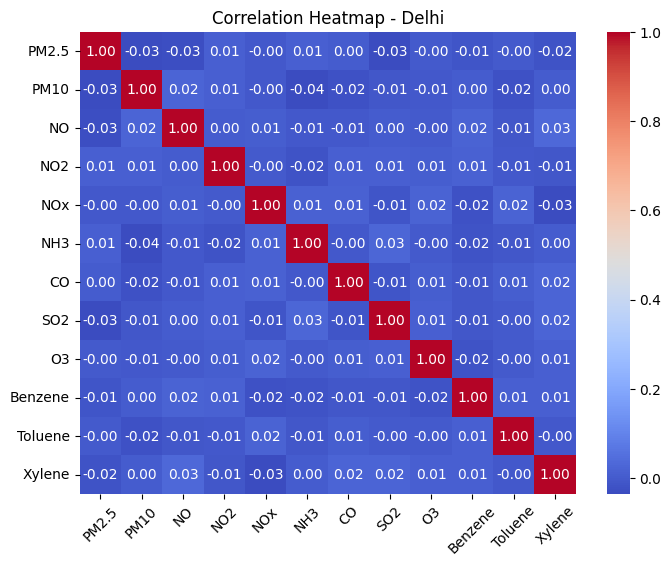

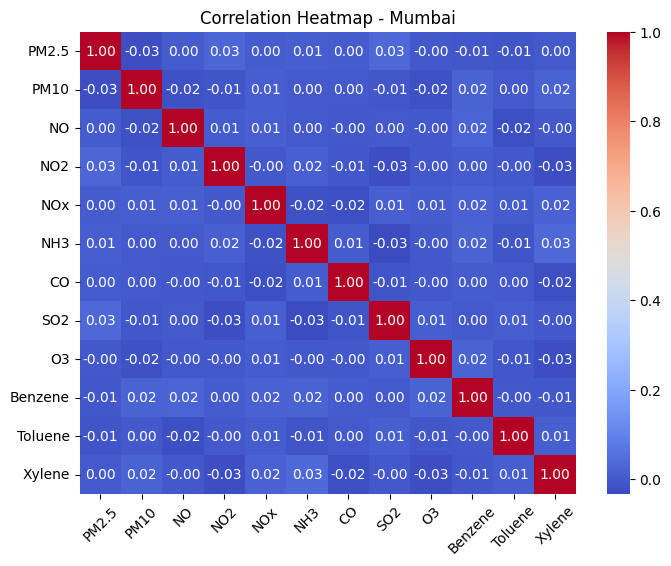

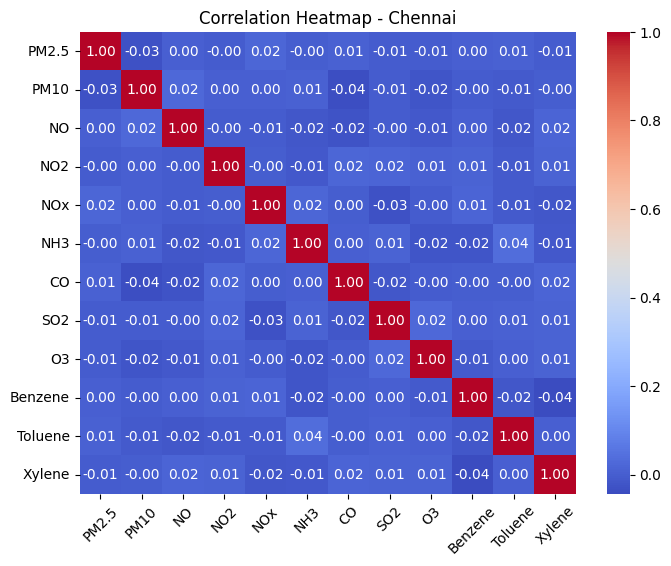

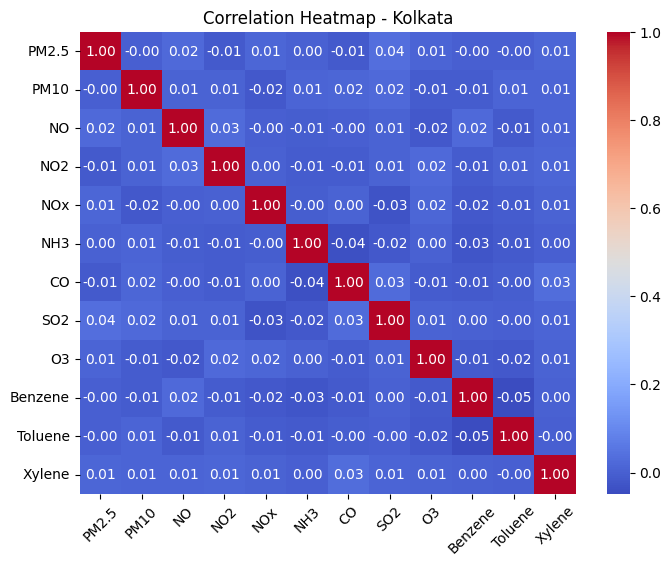

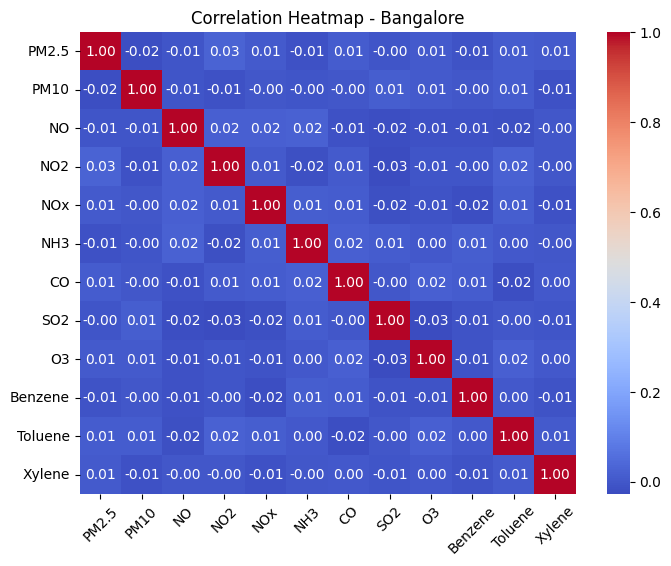

In [82]:
for city in df['City'].unique():
    plt.figure(figsize=(8,6))
    city_df = df[df['City'] == city]
    corr = city_df[pollutants].corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Heatmap - {city}')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

In [83]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Week'] = df['Datetime'].dt.to_period('W')

weekly_df = df.groupby(['City','Week']).mean(numeric_only=True).reset_index()

In [84]:
# Loop through each unique city in the weekly aggregated dataset
for city in weekly_df['City'].unique():

    # Print the city name for which correlation is being computed
    print(f"\nWeekly correlation for {city}:\n")

    # Subset the dataset for the current city only
    # This ensures we analyze within-city relationships (important to avoid mixing patterns)
    city_df = weekly_df[weekly_df['City'] == city]

    corr = city_df[pollutants].corr()

    print(corr)


Weekly correlation for Bangalore:

            PM2.5      PM10        NO       NO2       NOx       NH3        CO       SO2        O3   Benzene   Toluene    Xylene
PM2.5    1.000000 -0.022563 -0.076025  0.001001  0.018695 -0.030892  0.110078 -0.042691 -0.025421  0.021643 -0.014425 -0.012174
PM10    -0.022563  1.000000 -0.021693 -0.050193 -0.020132 -0.011831 -0.013385  0.010449 -0.010781  0.010262  0.026607  0.027053
NO      -0.076025 -0.021693  1.000000 -0.025777  0.047831  0.082021 -0.009899 -0.078000  0.007835 -0.053891  0.008244  0.024714
NO2      0.001001 -0.050193 -0.025777  1.000000 -0.058976 -0.034670  0.086283  0.049104  0.042994  0.001752 -0.010105  0.068769
NOx      0.018695 -0.020132  0.047831 -0.058976  1.000000 -0.045386  0.016236  0.017075  0.032792 -0.074916 -0.028344 -0.107245
NH3     -0.030892 -0.011831  0.082021 -0.034670 -0.045386  1.000000  0.032133 -0.006968  0.044663 -0.008101 -0.044262  0.002705
CO       0.110078 -0.013385 -0.009899  0.086283  0.016236  0.032133 

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
weekly_df[pollutants] = scaler.fit_transform(weekly_df[pollutants])

In [86]:
# Import required libraries
import pandas as pd

# Convert 'Datetime' column to proper datetime format
# WHY: Ensures we can extract time-based features like week, month, etc.
df['Datetime'] = pd.to_datetime(df['Datetime'])


# Create a 'Week' variable using pandas Period
# WHAT: Converts each date into its corresponding week
# WHY: Daily data is very noisy; weekly aggregation smooths fluctuations and reveals trends
df['Week'] = df['Datetime'].dt.to_period('W')


# Aggregate data at City + Week level
# WHAT: Taking mean of AQI and all pollutants for each city-week combination
# WHY: This reduces random day-to-day noise and gives a stable representation of pollution levels
weekly_df = df.groupby(['City', 'Week']).mean(numeric_only=True).reset_index()


# Check first few rows to confirm transformation
# WHY: Always verify data after transformation to avoid silent errors
print(weekly_df.head())

        City                   Week     PM2.5      PM10        NO       NO2       NOx       NH3        CO       SO2        O3   Benzene   Toluene    Xylene       AQI    Year
0  Bangalore  2014-12-29/2015-01-04  4.488078  5.123553  5.001812  4.105184  4.619123  3.780303  1.239811  3.804340  4.631967  2.508351  2.445700  2.225018  5.687992  2015.0
1  Bangalore  2015-01-05/2015-01-11  5.588613  5.864585  3.560488  3.763554  4.005848  2.908363  1.580103  3.854136  4.362642  2.341416  2.990642  1.933674  5.098350  2015.0
2  Bangalore  2015-01-12/2015-01-18  5.152836  5.358255  4.646830  4.317326  5.281565  2.637997  1.755381  3.504364  3.843801  1.917380  2.635172  1.610853  4.688410  2015.0
3  Bangalore  2015-01-19/2015-01-25  5.268685  4.791547  4.116063  4.346734  4.605962  2.716960  1.745291  3.214416  4.866026  2.124079  2.927386  1.557762  4.953630  2015.0
4  Bangalore  2015-01-26/2015-02-01  5.380089  5.145621  4.118077  4.423757  4.394056  2.950348  1.656238  3.591213  3.984878  2.2

In [87]:
# -------------------------------
# STEP 2A: Convert Week to timestamp
# -------------------------------

# Convert 'Week' (which is currently a period) back to a timestamp
# WHAT: Changes weekly period into an actual date (start of the week)
# WHY: Needed because regression models work better with numeric or datetime formats
weekly_df['Week_start'] = weekly_df['Week'].dt.start_time


# -------------------------------
# STEP 2B: Create a Time index
# -------------------------------

# Sort data by City and Week to maintain chronological order
# WHY: Time index must follow correct sequence for each city
weekly_df = weekly_df.sort_values(['City', 'Week_start'])

# Create a time variable (running index within each city)
# WHAT: Assigns 1, 2, 3, ... for each week per city
# WHY: Captures long-term trend (increase/decrease in AQI over time)
weekly_df['Time'] = weekly_df.groupby('City').cumcount() + 1


# -------------------------------
# STEP 2C: Create Lockdown variable
# -------------------------------

# Define lockdown period (India lockdown: 25 March 2020 – 31 May 2020)
# WHAT: Create a binary variable (0 = no lockdown, 1 = lockdown period)
# WHY: This is your main variable of interest (to measure lockdown effect)
weekly_df['Lockdown'] = ((weekly_df['Week_start'] >= '2020-03-25') &
                         (weekly_df['Week_start'] <= '2020-05-31')).astype(int)


# -------------------------------
# STEP 2D: (Optional but recommended) Post-lockdown variable
# -------------------------------

# WHAT: Indicator for post-lockdown period
# WHY: Helps capture recovery or rebound effect after lockdown ends
weekly_df['PostLockdown'] = (weekly_df['Week_start'] > '2020-05-31').astype(int)


# -------------------------------
# STEP 2E: Quick check
# -------------------------------

# Display a few rows to verify variables
# WHY: Ensures that Time and Lockdown variables are correctly created
weekly_df[['City', 'Week_start', 'Time', 'Lockdown', 'PostLockdown']]

,City,Week_start,Time,Lockdown,PostLockdown
0,Bangalore,2014-12-29,1,0,0
1,Bangalore,2015-01-05,2,0,0
2,Bangalore,2015-01-12,3,0,0
3,Bangalore,2015-01-19,4,0,0
4,Bangalore,2015-01-26,5,0,0
...,...,...,...,...,...
2610,Mumbai,2024-12-02,519,0,1
2611,Mumbai,2024-12-09,520,0,1
2612,Mumbai,2024-12-16,521,0,1
2613,Mumbai,2024-12-23,522,0,1


In [88]:
# Import required libraries for regression
import statsmodels.api as sm
import statsmodels.formula.api as smf


# -------------------------------
# STEP 3A: Fit baseline regression model
# -------------------------------

# WHAT: We are fitting a linear regression model using statsmodels
# WHY: This model helps us estimate the effect of Lockdown on AQI,
#      while controlling for time trend and city-specific differences

# Model specification:
# AQI ~ Lockdown + Time + C(City)
# - AQI = dependent variable
# - Lockdown = main variable of interest
# - Time = controls long-term trend
# - C(City) = treats City as categorical (fixed effects)

model_baseline = smf.ols(
    formula='AQI ~ Lockdown + Time + C(City)',
    data=weekly_df
).fit()

print(model_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7180
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.635
Time:                        17:04:02   Log-Likelihood:                -1037.7
No. Observations:                2615   AIC:                             2089.
Df Residuals:                    2608   BIC:                             2130.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              5.2064      0

In [ ]:
# Import required function for quoting column names
from patsy import dmatrices, ModelDesc, Term, EvalFactor


# Convert pollutant names into safe format
# Q("PM2.5") instead of PM2.5
# Prevent syntax errors in regression formula
pollutants_quoted = [f'Q("{p}")' for p in pollutants]


# Build formula safely
# Combine all variables into regression formula
# This ensures model runs without syntax errors
formula = 'AQI ~ Lockdown + Time + C(City) + ' + ' + '.join(pollutants_quoted)


# Fit model
# Running corrected regression model
# Now statsmodels can correctly interpret all variables
model_full = smf.ols(formula=formula, data=weekly_df).fit()


print(model_full.summary())

In [ ]:
# Check correlation between AQI and PM2.5 (daily data)

print(df[['AQI', 'PM2.5']].corr())

In [ ]:
# Regress PM2.5 on lockdown, time, and city
# To measure how lockdown impacted pollution levels directly

model_pm25 = smf.ols(
    formula='Q("PM2.5") ~ Lockdown + Time + C(City)',
    data=weekly_df
).fit()

# Print results
print(model_pm25.summary())

In [ ]:
# Check summary statistics city-wise

print(df.groupby('City')[['AQI', 'PM2.5']].mean())

# Pollution should vary over time

print(df[['AQI', 'PM2.5']].describe())

# Look for obvious inconsistencies
print(df[['City', 'Datetime', 'AQI', 'PM2.5']])

In [ ]:
df.groupby(df['Datetime'].dt.year)[pollutants].corr()

In [ ]:
df['AQI_Bucket'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution")
plt.show()

In [ ]:
city_year_aqi = city_df.groupby('Year')['AQI'].mean()

city_year_aqi.plot(marker='o')
plt.title("Year-wise AQI for Delhi")
plt.show()

In [ ]:
pivot = df.pivot_table(values='AQI', index='City', columns='Year', aggfunc='mean')

sns.heatmap(pivot, cmap='coolwarm')
plt.title("AQI Heatmap (City vs Year)")
plt.show()

In [ ]:
# -------------------------------
# Convert datetime properly
# -------------------------------
df['Date'] = pd.to_datetime(df['Datetime'])   # use your correct column name

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# -------------------------------
# CLEAN COLUMN NAMES
# -------------------------------
# Remove spaces and special characters
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace(r'[^\w]', '', regex=True)

# Print to verify pollutant names
print("Columns after cleaning:")
print(df.columns)

# -------------------------------
# MONTHLY AGGREGATION (KEEP ALL POLLUTANTS)
# -------------------------------
monthly_df = df.groupby(['City', 'Year', 'Month']).agg({
    'AQI': 'mean',
    'PM25': 'mean',     # adjust if your column is PM2_5
    'PM10': 'mean',
    'NO': 'mean',
    'NO2': 'mean',
    'NOx': 'mean',
    'NH3': 'mean',
    'CO': 'mean',
    'SO2': 'mean',
    'O3': 'mean',
    'Benzene': 'mean',
    'Toluene': 'mean',
    'Xylene': 'mean'

}).reset_index()

# -------------------------------
# RENAME FOR CONSISTENCY (OPTIONAL BUT RECOMMENDED)
# -------------------------------
monthly_df = monthly_df.rename(columns={
    'PM25': 'PM2_5'
})

# -------------------------------
# CREATE TIME FEATURES
# -------------------------------
# Create proper datetime column
monthly_df['MonthStart'] = pd.to_datetime(monthly_df[['Year', 'Month']].assign(DAY=1))

# Sort properly
monthly_df = monthly_df.sort_values(['City', 'Year', 'Month'])

# Time index (trend)
monthly_df['TimeIndex'] = monthly_df.groupby('City').cumcount()

# Month as categorical (for seasonality)
monthly_df['Month'] = monthly_df['Month'].astype('category')

# -------------------------------
# OPTIONAL 3-MONTH ROLLING AVERAGE
# -------------------------------
monthly_df['AQI_3month_avg'] = monthly_df.groupby('City')['AQI'] \
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# -------------------------------
# FINAL CHECK
# -------------------------------
print("\nFinal columns in monthly_df:")
print(monthly_df.columns)

# View full dataframe
monthly_df

In [ ]:
for city in monthly_df['City'].unique():
    city_df = monthly_df[monthly_df['City'] == city]

    plt.figure()
    plt.plot(city_df['MonthStart'], city_df['AQI'], label='Monthly AQI')
    plt.plot(city_df['MonthStart'], city_df['AQI_3month_avg'], linestyle='--', label='3-month avg')

    plt.title(f"AQI Trend - {city}")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.legend()
    plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Time index (trend)
monthly_df = monthly_df.sort_values(['City', 'Year', 'Month'])
monthly_df['TimeIndex'] = monthly_df.groupby('City').cumcount()

# Month as categorical
monthly_df['Month'] = monthly_df['Month'].astype('category')